# 05 - Double Basic Autoencoder


## 🌐 Connect Colab to Google Drive

In [ ]:
from google.colab import drive

drive.mount("/gdrive")
%cd /gdrive/My Drive/[2024-2025] AN2DL

Mounted at /gdrive
/gdrive/My Drive/[2024-2025] AN2DL


## ⚙️ Import Libraries

In [ ]:
import random
import seaborn as sns
import DeepLearningLib as dll

In [ ]:
import os
from datetime import datetime

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.17.1
Keras version: 3.5.0
GPU devices: 1


## ⏳ Load the Data

In [ ]:
data = np.load("mars_for_students.npz")

training_set = data["training_set"]
X_train = training_set[:, 0]
y_train = training_set[:, 1]

X_test = data["test_set"]

print(f"Training X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Test X shape: {X_test.shape}")

Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


## 🛠️ Train and Save the Model

In [ ]:
# Add color channel and rescale pixels between 0 and 1
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

print(f"Input shape: {input_shape}")
print(f"Number of classes: {num_classes}")

Input shape: (64, 128, 1)
Number of classes: 5


In [ ]:
y_train = y_train[..., np.newaxis]
y_train.shape

(2615, 64, 128, 1)

In [ ]:
# Set batch size for training
BATCH_SIZE = 64

# Set learning rate for the optimiser
LEARNING_RATE = 1e-3

# Set early stopping patience threshold
PATIENCE = 30

# Set maximum number of training epochs
EPOCHS = 1000

# Set data split size for training and validation
SPLITS_SIZE = 300

In [ ]:
@tf.function
def random_horizontal_flip(image, label, seed=None):
    """Consistent random horizontal flip."""
    if seed is None:
        seed = np.random.randint(0, 1000000)
    flip_prob = tf.random.uniform([], seed=seed)
    image = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.flip_left_right(image),
        lambda: image
    )
    label = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.flip_left_right(label),
        lambda: label
    )
    return image, label

@tf.function
def random_vertical_flip(image, label, seed=None):
    """Consistent random horizontal flip."""
    if seed is None:
        seed = np.random.randint(0, 1000000)
    flip_prob = tf.random.uniform([], seed=seed)
    image = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.flip_up_down(image),
        lambda: image
    )
    label = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.flip_up_down(label),
        lambda: label
    )
    return image, label

@tf.function
def random_brightness(image, label, seed=None):
    """Consistent random horizontal flip."""
    if seed is None:
        seed = np.random.randint(0, 1000000)
    flip_prob = tf.random.uniform([], seed=seed)
    image = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.stateless_random_brightness(image, max_delta=.2, seed=seed),
        lambda: image
    )
    # label = tf.cond(
    #     flip_prob > 0.5,
    #     lambda: tf.image.stateless_random_brightness(image, max_delta=.2, seed=seed),
    #     lambda: label
    # )
    return image, label

@tf.function
def random_contrast(image, label, seed=None):
    """Consistent random horizontal flip."""
    if seed is None:
        seed = np.random.randint(0, 1000000)
    flip_prob = tf.random.uniform([], seed=seed)
    image = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.stateless_random_contrast(image, lower=0.8, upper=1.2, seed=seed),
        lambda: image
    )
    # label = tf.cond(
    #     flip_prob > 0.5,
    #     lambda: tf.image.stateless_random_contrast(image, lower=0.8, upper=1.2, seed=seed),
    #     lambda: label
    # )
    return image, label

@tf.function
def random_crop(image, label, seed=None):
    """Consistent random horizontal flip."""
    if seed is None:
        seed = np.random.randint(0, 1000000)
    flip_prob = tf.random.uniform([], seed=seed)
    image = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.stateless_random_crop(image, size=(32, 64, 1), seed=seed),
        lambda: image
    )
    label = tf.cond(
        flip_prob > 0.5,
        lambda: tf.image.stateless_random_crop(image, size=(32, 64, 1), seed=seed),
        lambda: label
    )
    return image, label

In [ ]:
def make_dataset(X, y, batch_size=64, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    # Create dataset from file paths
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
train_img, val_img, train_lbl, val_lbl = train_test_split(
    X_train, y_train, test_size=300, random_state=42
)
print("Data splitted!")

print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

Data splitted!

Number of images:
Train: 2315
Validation: 300


In [ ]:
def unet_block(input_tensor, filters, kernel_size=3, activation='relu', stack=2, name=''):
    # Initialise the input tensor
    x = input_tensor

    # Apply a sequence of Conv2D, Batch Normalisation, and Activation layers for the specified number of stacks
    for i in range(stack):
        x = tfkl.Conv2D(filters, kernel_size=kernel_size, padding='same', name=name + 'conv' + str(i + 1))(x)
        x = tfkl.BatchNormalization(name=name + 'bn' + str(i + 1))(x)
        x = tfkl.Activation(activation, name=name + 'activation' + str(i + 1))(x)

    # Return the transformed tensor
    return x

### Train with Augmentation One (Only vertical and horizontal flips)

In [ ]:
def make_dataset_augOne(image_paths, label_paths, batch_size, shuffle=False, augment=False, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    # Create dataset from file paths
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, label_paths))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    if augment:
        dataset = dataset.map(
            lambda x, y: random_horizontal_flip(x, y, seed=seed),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        dataset = dataset.map(
            lambda x, y: random_vertical_flip(x, y, seed=seed),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Create the datasets
print("Creating datasets...")
train_dataset = make_dataset_augOne(
    train_img, train_lbl,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True,
    seed=42
)

val_dataset = make_dataset_augOne(
    val_img, val_lbl,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets created!")

# Check the shape of the data
for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"\nInput shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels dtype:", labels.dtype)
    break

Creating datasets...
Datasets created!

Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Labels dtype: <dtype: 'float64'>


In [ ]:
seed = 42

tf.random.set_seed(seed)
input_layer = tfkl.Input(shape=input_shape, name='input_layer')

# Downsampling path 1
down1_block_1 = unet_block(input_layer, 32, name='down1_block1_')
d11 = tfkl.MaxPooling2D()(down1_block_1)

down1_block_2 = unet_block(d11, 64, name='down1_block2_')
d12 = tfkl.MaxPooling2D()(down1_block_2)

# Bottleneck 1
bottleneck1 = unet_block(d12, 128, name='bottleneck1')

# Upsampling path 1
u11 = tfkl.UpSampling2D()(bottleneck1)
u11 = tfkl.Concatenate()([u11, down1_block_2])
u11 = unet_block(u11, 64, name='up1_block1_')

u12 = tfkl.UpSampling2D()(u11)
u12 = tfkl.Concatenate()([u12, down1_block_1])
u12 = unet_block(u12, 32, name='up1_block2_')

# Downsampling path 2
down2_block_1 = unet_block(u12, 32, name='down2_block1_')
d21 = tfkl.MaxPooling2D()(down2_block_1)

down2_block_2 = unet_block(d21, 64, name='down2_block2_')
d22 = tfkl.MaxPooling2D()(down2_block_2)

# Bottleneck 2
bottleneck2 = unet_block(d22, 128, name='bottleneck2')

# Upsampling path 2
u21 = tfkl.UpSampling2D()(bottleneck2)
u21 = tfkl.Concatenate()([u21, down2_block_2])
u21 = unet_block(u21, 64, name='up2_block1_')

u22 = tfkl.UpSampling2D()(u21)
u22 = tfkl.Concatenate()([u22, down2_block_1])
u22 = unet_block(u22, 32, name='up2_block2_')

# Output Layer
output_layer = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation="softmax", name='output_layer')(u22)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='DoubleUNet')

# Define the MeanIoU ignoring the background class
mean_iou = tfk.metrics.MeanIoU(num_classes=num_classes, ignore_class=0, sparse_y_pred=False)

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=[mean_iou, "accuracy"])

model.summary()

Model: "DoubleUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 128, 1)     │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_conv1        │ (None, 64, 128, 32)    │            320 │ input_layer[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_bn1          │ (None, 64, 128, 32)    │            128 │ down1_block1_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_activation1  │ (None, 64, 128, 32)    │              0 │ down1_block1_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_conv2        │ (None, 64, 128, 32)    │          9,248 │ down1_block1_activati… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_bn2          │ (None, 64, 128, 32)    │            128 │ down1_block1_conv2[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_activation2  │ (None, 64, 128, 32)    │              0 │ down1_block1_bn2[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 32, 64, 32)     │              0 │ down1_block1_activati… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_conv1        │ (None, 32, 64, 64)     │         18,496 │ max_pooling2d_4[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_bn1          │ (None, 32, 64, 64)     │            256 │ down1_block2_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_activation1  │ (None, 32, 64, 64)     │              0 │ down1_block2_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_conv2        │ (None, 32, 64, 64)     │         36,928 │ down1_block2_activati… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_bn2          │ (None, 32, 64, 64)     │            256 │ down1_block2_conv2[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_activati

 Total params: 956,101 (3.65 MB)

 Trainable params: 953,541 (3.64 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
# Setup callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=PATIENCE,
    restore_best_weights=True
)

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping],
    verbose=1
).history

Epoch 1/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 590ms/step - accuracy: 0.3991 - loss: 1.4184 - mean_io_u_1: 0.1874 - val_accuracy: 0.1883 - val_loss: 1.9371 - val_mean_io_u_1: 0.0642
Epoch 2/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.5517 - loss: 1.1248 - mean_io_u_1: 0.2851 - val_accuracy: 0.1883 - val_loss: 1.9439 - val_mean_io_u_1: 0.0642
Epoch 3/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - accuracy: 0.5721 - loss: 1.0668 - mean_io_u_1: 0.2983 - val_accuracy: 0.1883 - val_loss: 2.6577 - val_mean_io_u_1: 0.0642
Epoch 4/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - accuracy: 0.5632 - loss: 1.0677 - mean_io_u_1: 0.2884 - val_accuracy: 0.1883 - val_loss: 3.5941 - val_mean_io_u_1: 0.0642
Epoch 5/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.6307 - loss: 0.9507 - mean_io_u_1: 0.3452 - val_accuracy: 0.1884 - val_loss: 2.4572 - val_mean_io_u_1: 0.0513
Epoch 6/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 256ms/step - accuracy: 0.6489 - loss: 0.8987 - mean_io_u_1: 0.

In [ ]:
timestep_str = datetime.now().strftime("%y%m%d_%H%M%S")
model_filename = f"model_{timestep_str}.keras"
model.save(model_filename)
del model

print(f"Model saved to {model_filename}")

Model saved to model_241203_071507.keras


#05 - Double Basic Autoencoder whith Oversampled Dataset by Image Generation and Image Reuse


## ⏳ Load the Data

In [ ]:
data = np.load("mars_for_students.npz")
train = np.load('oversampled_normalized_train_mars_for_students.npz')

X_train = train['images']
y_train = train['labels']

X_test = data["test_set"]

print(f"Training X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Test X shape: {X_test.shape}")

Training X shape: (3555, 64, 128, 1)
Training y shape: (3555, 64, 128, 1)
Test X shape: (10022, 64, 128)


## 🛠️ Train and Save the Model

In [ ]:
# Add color channel and rescale pixels between 0 and 1
X_test = X_test[..., np.newaxis] / 255.0

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

print(f"Input shape: {input_shape}")
print(f"Number of classes: {num_classes}")

Input shape: (64, 128, 1)
Number of classes: 5


In [ ]:
# Set batch size for training
BATCH_SIZE = 64

# Set learning rate for the optimiser
LEARNING_RATE = 1e-3

# Set early stopping patience threshold
PATIENCE = 30

# Set maximum number of training epochs
EPOCHS = 1000

# Set data split size for training and validation
SPLITS_SIZE = 300

In [ ]:
train_img, val_img, train_lbl, val_lbl = train_test_split(
    X_train, y_train, test_size=300, random_state=42
)
print("Data splitted!")

print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

Data splitted!

Number of images:
Train: 3255
Validation: 300


### Train with Augmentation One (Only vertical and horizontal flips)

In [ ]:
def make_dataset_augOne_MixedApp(X, y, batch_size, shuffle=False, augment=False, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    # Create dataset from file paths
    dataset_with4 = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.equal(y, 4)))
    dataset_rest = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.not_equal(y, 4)))
    dataset = tf.data.Dataset.sample_from_datasets(
        [dataset_with4, dataset_rest],
        weights=[.35, .65])

    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    if augment:
        dataset = dataset.map(
            lambda x, y: random_horizontal_flip(x, y, seed=seed),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        dataset = dataset.map(
            lambda x, y: random_vertical_flip(x, y, seed=seed),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Create the datasets
print("Creating datasets...")
train_dataset = make_dataset_augOne_MixedApp(
    train_img, train_lbl,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True,
    seed=42
)

val_dataset = make_dataset_augOne_MixedApp(
    val_img, val_lbl,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets created!")

# Check the shape of the data
for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"\nInput shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels dtype:", labels.dtype)
    break

Creating datasets...
Datasets created!

Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Labels dtype: <dtype: 'int64'>


In [ ]:
seed = 42

tf.random.set_seed(seed)
input_layer = tfkl.Input(shape=input_shape, name='input_layer')

# Downsampling path 1
down1_block_1 = unet_block(input_layer, 32, name='down1_block1_')
d11 = tfkl.MaxPooling2D()(down1_block_1)

down1_block_2 = unet_block(d11, 64, name='down1_block2_')
d12 = tfkl.MaxPooling2D()(down1_block_2)

# Bottleneck 1
bottleneck1 = unet_block(d12, 128, name='bottleneck1')

# Upsampling path 1
u11 = tfkl.UpSampling2D()(bottleneck1)
u11 = tfkl.Concatenate()([u11, down1_block_2])
u11 = unet_block(u11, 64, name='up1_block1_')

u12 = tfkl.UpSampling2D()(u11)
u12 = tfkl.Concatenate()([u12, down1_block_1])
u12 = unet_block(u12, 32, name='up1_block2_')

# Downsampling path 2
down2_block_1 = unet_block(u12, 32, name='down2_block1_')
d21 = tfkl.MaxPooling2D()(down2_block_1)

down2_block_2 = unet_block(d21, 64, name='down2_block2_')
d22 = tfkl.MaxPooling2D()(down2_block_2)

# Bottleneck 2
bottleneck2 = unet_block(d22, 128, name='bottleneck2')

# Upsampling path 2
u21 = tfkl.UpSampling2D()(bottleneck2)
u21 = tfkl.Concatenate()([u21, down2_block_2])
u21 = unet_block(u21, 64, name='up2_block1_')

u22 = tfkl.UpSampling2D()(u21)
u22 = tfkl.Concatenate()([u22, down2_block_1])
u22 = unet_block(u22, 32, name='up2_block2_')

# Output Layer
output_layer = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation="softmax", name='output_layer')(u22)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='DoubleUNet')

# Define the MeanIoU ignoring the background class
mean_iou = tfk.metrics.MeanIoU(num_classes=num_classes, ignore_class=0, sparse_y_pred=False)

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=[mean_iou, "accuracy"])

model.summary()

Model: "DoubleUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 128, 1)     │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_conv1        │ (None, 64, 128, 32)    │            320 │ input_layer[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_bn1          │ (None, 64, 128, 32)    │            128 │ down1_block1_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_activation1  │ (None, 64, 128, 32)    │              0 │ down1_block1_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_conv2        │ (None, 64, 128, 32)    │          9,248 │ down1_block1_activati… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_bn2          │ (None, 64, 128, 32)    │            128 │ down1_block1_conv2[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_activation2  │ (None, 64, 128, 32)    │              0 │ down1_block1_bn2[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 32, 64, 32)     │              0 │ down1_block1_activati… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_conv1        │ (None, 32, 64, 64)     │         18,496 │ max_pooling2d_8[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_bn1          │ (None, 32, 64, 64)     │            256 │ down1_block2_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_activation1  │ (None, 32, 64, 64)     │              0 │ down1_block2_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_conv2        │ (None, 32, 64, 64)     │         36,928 │ down1_block2_activati… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_bn2          │ (None, 32, 64, 64)     │            256 │ down1_block2_conv2[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_activati

 Total params: 956,101 (3.65 MB)

 Trainable params: 953,541 (3.64 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
# Setup callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=PATIENCE,
    restore_best_weights=True
)

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping],
    verbose=1
).history

Epoch 1/1000
     65/Unknown 52s 476ms/step - accuracy: 0.4394 - loss: 1.3473 - mean_io_u_2: 0.1495

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


65/65 ━━━━━━━━━━━━━━━━━━━━ 56s 531ms/step - accuracy: 0.4401 - loss: 1.3458 - mean_io_u_2: 0.1501 - val_accuracy: 0.2405 - val_loss: 1.7950 - val_mean_io_u_2: 0.0668
Epoch 2/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - accuracy: 0.5386 - loss: 1.1331 - mean_io_u_2: 0.2462 - val_accuracy: 0.2405 - val_loss: 3.4283 - val_mean_io_u_2: 0.0668
Epoch 3/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.5572 - loss: 1.0900 - mean_io_u_2: 0.2631 - val_accuracy: 0.2374 - val_loss: 1.8459 - val_mean_io_u_2: 0.0444
Epoch 4/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.5970 - loss: 1.0154 - mean_io_u_2: 0.2977 - val_accuracy: 0.2435 - val_loss: 1.9477 - val_mean_io_u_2: 0.0652
Epoch 5/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.6060 - loss: 1.0021 - mean_io_u_2: 0.3105 - val_accuracy: 0.2407 - val_loss: 2.8745 - val_mean_io_u_2: 0.0673
Epoch 6/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.6242 - loss: 0.9678 - mean_io_u_2: 0.3226 - val_a

In [ ]:
timestep_str = datetime.now().strftime("%y%m%d_%H%M%S")
model_filename = f"model_{timestep_str}.keras"
model.save(model_filename)
del model

print(f"Model saved to {model_filename}")

Model saved to model_241203_074733.keras


# 05 - Double Basic Autoencoder Plus More Skip Connections with Oversampled Dataset by Image Generation and Image Reuse

## ⏳ Load the Data

In [ ]:
data = np.load("mars_for_students.npz")
train = np.load('oversampled_normalized_train_mars_for_students.npz')

X_train = train['images']
y_train = train['labels']

X_test = data["test_set"]

print(f"Training X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Test X shape: {X_test.shape}")

Training X shape: (3555, 64, 128, 1)
Training y shape: (3555, 64, 128, 1)
Test X shape: (10022, 64, 128)


## 🛠️ Train and Save the Model

In [ ]:
# Add color channel and rescale pixels between 0 and 1
X_test = X_test[..., np.newaxis] / 255.0

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

print(f"Input shape: {input_shape}")
print(f"Number of classes: {num_classes}")

Input shape: (64, 128, 1)
Number of classes: 5


In [ ]:
# Set batch size for training
BATCH_SIZE = 64

# Set learning rate for the optimiser
LEARNING_RATE = 1e-3

# Set early stopping patience threshold
PATIENCE = 30

# Set maximum number of training epochs
EPOCHS = 1000

# Set data split size for training and validation
SPLITS_SIZE = 300

In [ ]:
train_img, val_img, train_lbl, val_lbl = train_test_split(
    X_train, y_train, test_size=300, random_state=42
)
print("Data splitted!")

print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

Data splitted!

Number of images:
Train: 3255
Validation: 300


### Train with Augmentation One (Only vertical and horizontal flips)

In [ ]:
def make_dataset_augOne_MixedApp(X, y, batch_size, shuffle=False, augment=False, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    # Create dataset from file paths
    dataset_with4 = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.equal(y, 4)))
    dataset_rest = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.not_equal(y, 4)))
    dataset = tf.data.Dataset.sample_from_datasets(
        [dataset_with4, dataset_rest],
        weights=[.35, .65])

    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    if augment:
        dataset = dataset.map(
            lambda x, y: random_horizontal_flip(x, y, seed=seed),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        dataset = dataset.map(
            lambda x, y: random_vertical_flip(x, y, seed=seed),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Create the datasets
print("Creating datasets...")
train_dataset = make_dataset_augOne_MixedApp(
    train_img, train_lbl,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True,
    seed=42
)

val_dataset = make_dataset_augOne_MixedApp(
    val_img, val_lbl,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets created!")

# Check the shape of the data
for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"\nInput shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels dtype:", labels.dtype)
    break

Creating datasets...
Datasets created!

Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Labels dtype: <dtype: 'int64'>


In [ ]:
seed = 42

tf.random.set_seed(seed)
input_layer = tfkl.Input(shape=input_shape, name='input_layer')

# Downsampling path 1
down1_block_1 = unet_block(input_layer, 32, name='down1_block1_')
d11 = tfkl.MaxPooling2D()(down1_block_1)

down1_block_2 = unet_block(d11, 64, name='down1_block2_')
d12 = tfkl.MaxPooling2D()(down1_block_2)

# Bottleneck 1
bottleneck1 = unet_block(d12, 128, name='bottleneck1')

# Upsampling path 1
u11 = tfkl.UpSampling2D()(bottleneck1)
u11 = tfkl.Concatenate()([u11, down1_block_2])
u11 = unet_block(u11, 64, name='up1_block1_')

u12 = tfkl.UpSampling2D()(u11)
u12 = tfkl.Concatenate()([u12, down1_block_1])
u12 = unet_block(u12, 32, name='up1_block2_')

# Downsampling path 2
down2_block_1 = unet_block(u12, 32, name='down2_block1_')
d21 = tfkl.Concatenate()([d21, u11])
d21 = tfkl.MaxPooling2D()(down2_block_1)

down2_block_2 = unet_block(d21, 64, name='down2_block2_')
d22 = tfkl.Concatenate()([d22, bottleneck1])
d22 = tfkl.MaxPooling2D()(down2_block_2)

# Bottleneck 2
bottleneck2 = unet_block(d22, 128, name='bottleneck2')

# Upsampling path 2
u21 = tfkl.UpSampling2D()(bottleneck2)
u21 = tfkl.Concatenate()([u21, down2_block_2, down1_block_2])
u21 = unet_block(u21, 64, name='up2_block1_')

u22 = tfkl.UpSampling2D()(u21)
u22 = tfkl.Concatenate()([u22, down2_block_1, down1_block_1])
u22 = unet_block(u22, 32, name='up2_block2_')

# Output Layer
output_layer = tfkl.Conv2D(num_classes, kernel_size=1, padding='same', activation="softmax", name='output_layer')(u22)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name='DoubleUNet')

# Define the MeanIoU ignoring the background class
mean_iou = tfk.metrics.MeanIoU(num_classes=num_classes, ignore_class=0, sparse_y_pred=False)

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=[mean_iou, "accuracy"])

model.summary()

Model: "DoubleUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 128, 1)     │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_conv1        │ (None, 64, 128, 32)    │            320 │ input_layer[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_bn1          │ (None, 64, 128, 32)    │            128 │ down1_block1_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_activation1  │ (None, 64, 128, 32)    │              0 │ down1_block1_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_conv2        │ (None, 64, 128, 32)    │          9,248 │ down1_block1_activati… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_bn2          │ (None, 64, 128, 32)    │            128 │ down1_block1_conv2[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block1_activation2  │ (None, 64, 128, 32)    │              0 │ down1_block1_bn2[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_24          │ (None, 32, 64, 32)     │              0 │ down1_block1_activati… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_conv1        │ (None, 32, 64, 64)     │         18,496 │ max_pooling2d_24[0][0] │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_bn1          │ (None, 32, 64, 64)     │            256 │ down1_block2_conv1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_activation1  │ (None, 32, 64, 64)     │              0 │ down1_block2_bn1[0][0] │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_conv2        │ (None, 32, 64, 64)     │         36,928 │ down1_block2_activati… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_bn2          │ (None, 32, 64, 64)     │            256 │ down1_block2_conv2[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ down1_block2_activati

 Total params: 1,002,181 (3.82 MB)

 Trainable params: 999,621 (3.81 MB)

 Non-trainable params: 2,560 (10.00 KB)

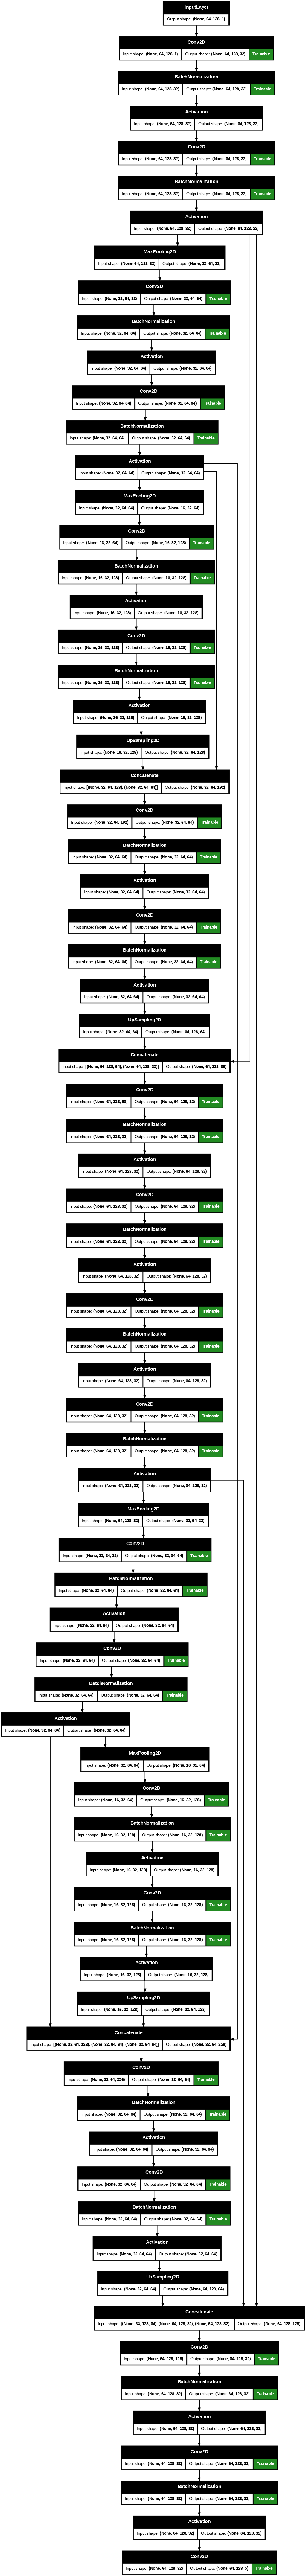

In [ ]:
# Plot the model architecture
tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

In [ ]:
# Setup callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=PATIENCE,
    restore_best_weights=True
)

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping],
    verbose=1
).history

Epoch 1/1000
     65/Unknown 58s 442ms/step - accuracy: 0.4465 - loss: 1.3766 - mean_io_u_4: 0.1857

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


65/65 ━━━━━━━━━━━━━━━━━━━━ 63s 518ms/step - accuracy: 0.4474 - loss: 1.3747 - mean_io_u_4: 0.1863 - val_accuracy: 0.2405 - val_loss: 2.2930 - val_mean_io_u_4: 0.0668
Epoch 2/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 46s 240ms/step - accuracy: 0.5553 - loss: 1.1063 - mean_io_u_4: 0.2503 - val_accuracy: 0.2411 - val_loss: 3.3063 - val_mean_io_u_4: 0.0699
Epoch 3/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.5724 - loss: 1.0522 - mean_io_u_4: 0.2745 - val_accuracy: 0.2405 - val_loss: 2.7767 - val_mean_io_u_4: 0.0668
Epoch 4/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.6049 - loss: 0.9975 - mean_io_u_4: 0.3048 - val_accuracy: 0.2411 - val_loss: 2.4201 - val_mean_io_u_4: 0.0668
Epoch 5/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.6054 - loss: 0.9938 - mean_io_u_4: 0.3092 - val_accuracy: 0.2415 - val_loss: 2.4527 - val_mean_io_u_4: 0.0672
Epoch 6/1000
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.6346 - loss: 0.9415 - mean_io_u_4: 0.3372 - val_a

In [ ]:
timestep_str = datetime.now().strftime("%y%m%d_%H%M%S")
model_filename = f"model_{timestep_str}.keras"
model.save(model_filename)
del model

print(f"Model saved to {model_filename}")

Model saved to model_241203_082050.keras


## 📊 Prepare Your Submission

In our Kaggle competition, submissions are made as `csv` files. To create a proper `csv` file, you need to flatten your predictions and include an `id` column as the first column of your dataframe. To maintain consistency between your results and our solution, please avoid shuffling the test set. The code below demonstrates how to prepare the `csv` file from your model predictions.




In [ ]:
# If model_filename is not defined, load the most recent model from Google Drive
if "model_filename" not in globals() or model_filename is None:
    files = [f for f in os.listdir('.') if os.path.isfile(f) and f.startswith('model_') and f.endswith('.keras')]
    files.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    if files:
        model_filename = files[0]
    else:
        raise FileNotFoundError("No model files found in the current directory.")

In [ ]:
model = tfk.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

Model loaded from model_241203_082050.keras


In [ ]:
preds = model.predict(X_test)
preds = np.argmax(preds, axis=-1)
print(f"Predictions shape: {preds.shape}")

314/314 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step
Predictions shape: (10022, 64, 128)


In [ ]:
def y_to_df(y) -> pd.DataFrame:
    """Converts segmentation predictions into a DataFrame format for Kaggle."""
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

In [ ]:
# Create and download the csv submission file
timestep_str = model_filename.replace("model_", "").replace(".keras", "")
submission_filename = f"submission_{timestep_str}.csv"
submission_df = y_to_df(preds)
submission_df.to_csv(submission_filename, index=False)

from google.colab import files
files.download(submission_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>